In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="darkgrid")

# Load core files
results      = pd.read_csv('../data/raw/results.csv')
drivers      = pd.read_csv('../data/raw/drivers.csv')
constructors = pd.read_csv('../data/raw/constructors.csv')
races        = pd.read_csv('../data/raw/races.csv')
qualifying   = pd.read_csv('../data/raw/qualifying.csv')
pit_stops    = pd.read_csv('../data/raw/pit_stops.csv')
standings    = pd.read_csv('../data/raw/driver_standings.csv')

print("✅ All files loaded!")

✅ All files loaded!


In [10]:
tables = {
    'results': results,
    'drivers': drivers,
    'constructors': constructors,
    'races': races,
    'qualifying': qualifying,
    'pit_stops': pit_stops,
    'standings': standings
}

for name, df in tables.items():
    print(f"\n📄 {name}: {df.shape[0]} rows × {df.shape[1]} cols")
    print(f"   Columns: {list(df.columns)}")


📄 results: 26759 rows × 18 cols
   Columns: ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId']

📄 drivers: 861 rows × 9 cols
   Columns: ['driverId', 'driverRef', 'number', 'code', 'forename', 'surname', 'dob', 'nationality', 'url']

📄 constructors: 212 rows × 5 cols
   Columns: ['constructorId', 'constructorRef', 'name', 'nationality', 'url']

📄 races: 1125 rows × 18 cols
   Columns: ['raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time', 'url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time']

📄 qualifying: 10494 rows × 9 cols
   Columns: ['qualifyId', 'raceId', 'driverId', 'constructorId', 'number', 'position', 'q1', 'q2', 'q3']

📄 pit_stops: 11371 rows × 7 cols
   Columns: ['raceId', 'driverId', 'stop', 'lap', 'time', 

In [11]:
# See the first few rows
results.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


In [12]:
# Check for missing values
results.isnull().sum()

resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
dtype: int64

In [13]:
# What does positionOrder look like? (this will be our target variable)
results['positionOrder'].value_counts().sort_index().head(20)

positionOrder
1     1128
2     1134
3     1135
4     1135
5     1132
6     1132
7     1132
8     1132
9     1131
10    1130
11    1133
12    1130
13    1126
14    1122
15    1120
16    1107
17    1100
18    1085
19    1062
20    1046
Name: count, dtype: int64

C:\Users\Utkarsh\AppData\Local\Temp\ipykernel_12460\4198123814.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_winners.values, y=top_winners.index, palette='flare')
C:\Users\Utkarsh\AppData\Local\Temp\ipykernel_12460\4198123814.py:12: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
U:\f1-race-predictor\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


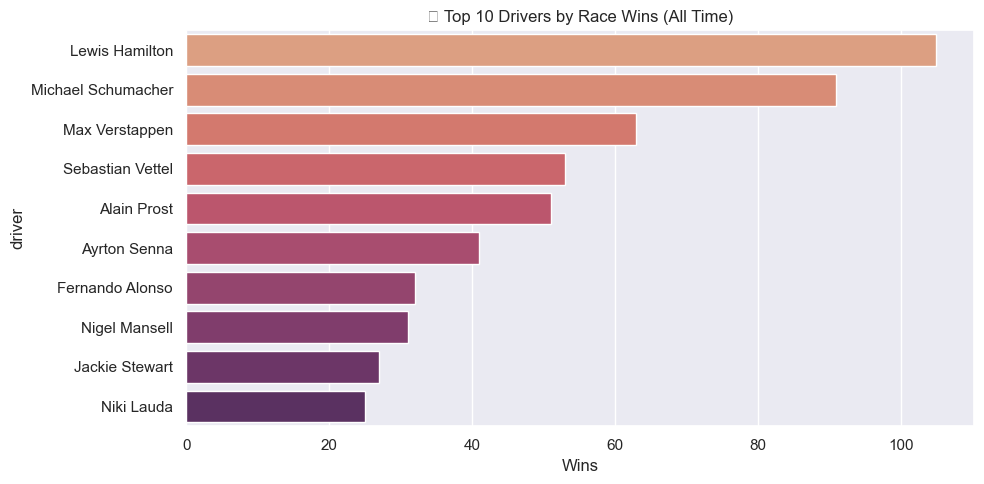

In [14]:
# Merge results with drivers to get names
wins = results[results['positionOrder'] == 1]
wins = wins.merge(drivers[['driverId', 'forename', 'surname']], on='driverId')
wins['driver'] = wins['forename'] + ' ' + wins['surname']

top_winners = wins['driver'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_winners.values, y=top_winners.index, palette='flare')
plt.title('🏆 Top 10 Drivers by Race Wins (All Time)')
plt.xlabel('Wins')
plt.tight_layout()
plt.show()

C:\Users\Utkarsh\AppData\Local\Temp\ipykernel_12460\2674802773.py:8: UserWarning: Glyph 127937 (\N{CHEQUERED FLAG}) missing from font(s) Arial.
  plt.tight_layout()
U:\f1-race-predictor\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127937 (\N{CHEQUERED FLAG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


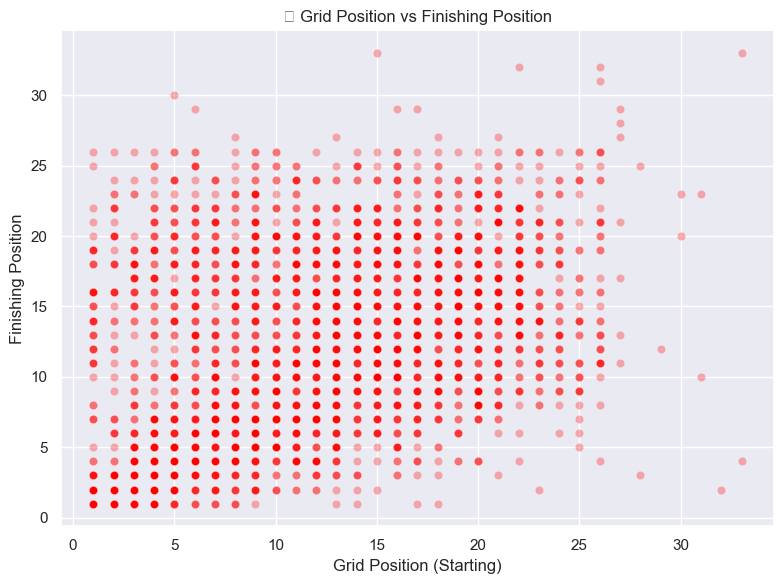

In [15]:
sample = results[results['grid'] > 0].sample(3000, random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=sample, x='grid', y='positionOrder', alpha=0.3, color='red')
plt.title('🏁 Grid Position vs Finishing Position')
plt.xlabel('Grid Position (Starting)')
plt.ylabel('Finishing Position')
plt.tight_layout()
plt.show()

C:\Users\Utkarsh\AppData\Local\Temp\ipykernel_12460\3456464908.py:17: UserWarning: Glyph 127950 (\N{RACING CAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Utkarsh\AppData\Local\Temp\ipykernel_12460\3456464908.py:17: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()


<Figure size 1200x500 with 0 Axes>

U:\f1-race-predictor\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127950 (\N{RACING CAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
U:\f1-race-predictor\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


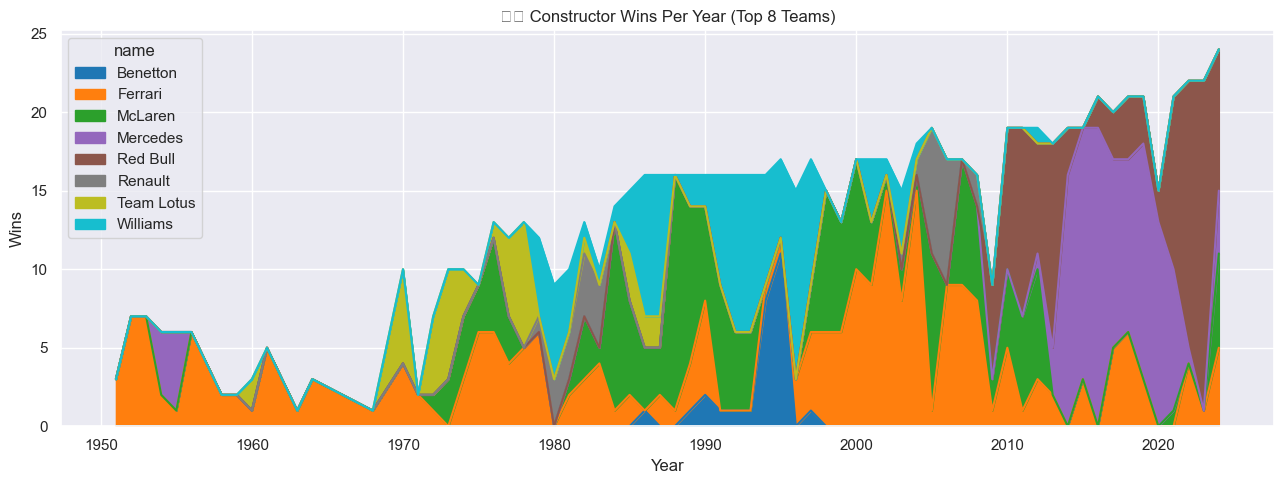

In [16]:
wins_con = results[results['positionOrder'] == 1].merge(
    races[['raceId', 'year']], on='raceId'
).merge(
    constructors[['constructorId', 'name']], on='constructorId'
)

top_teams = wins_con['name'].value_counts().head(8).index
data_plot = wins_con[wins_con['name'].isin(top_teams)]

plt.figure(figsize=(12, 5))
data_plot.groupby(['year', 'name']).size().unstack().fillna(0).plot(
    kind='area', stacked=True, figsize=(13, 5), colormap='tab10'
)
plt.title('🏎️ Constructor Wins Per Year (Top 8 Teams)')
plt.xlabel('Year')
plt.ylabel('Wins')
plt.tight_layout()
plt.show()